<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

Análisis explotario de datos 

Importar Librerías

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as st
import math as mt
import seaborn as sns
import matplotlib.pyplot as plt

Cargar archivos

In [2]:
df_company = pd.read_csv("/datasets/project_sql_result_01.csv")
df_neighborhoods = pd.read_csv("/datasets/project_sql_result_04.csv")
df_weather = pd.read_csv("/datasets/project_sql_result_07.csv")

Estudiar datos

Dataframe Company

In [3]:
print(df_company.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [4]:
print(df_company.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


In [5]:
df_company.dtypes

company_name    object
trips_amount     int64
dtype: object

In [6]:
df_company.duplicated

<bound method DataFrame.duplicated of                        company_name  trips_amount
0                         Flash Cab         19558
1         Taxi Affiliation Services         11422
2                 Medallion Leasing         10367
3                        Yellow Cab          9888
4   Taxi Affiliation Service Yellow          9299
..                              ...           ...
59     4053 - 40193 Adwar H. Nikola             7
60          2733 - 74600 Benny Jona             7
61    5874 - 73628 Sergey Cab Corp.             5
62       2241 - 44667 - Felman Corp             3
63      3556 - 36214 RC Andrews Cab             2

[64 rows x 2 columns]>

In [7]:
df_neighborhoods.isnull().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

Dataframe neighborhoods

In [8]:
print(df_neighborhoods.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [9]:
print(df_neighborhoods.head())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


Tipo de datos

In [10]:
df_neighborhoods.dtypes

dropoff_location_name     object
average_trips            float64
dtype: object

In [11]:
df_neighborhoods.duplicated

<bound method DataFrame.duplicated of    dropoff_location_name  average_trips
0                   Loop   10727.466667
1            River North    9523.666667
2          Streeterville    6664.666667
3              West Loop    5163.666667
4                 O'Hare    2546.900000
..                   ...            ...
89       Mount Greenwood       3.137931
90             Hegewisch       3.117647
91              Burnside       2.333333
92             East Side       1.961538
93             Riverdale       1.800000

[94 rows x 2 columns]>

In [12]:
df_neighborhoods.isnull().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

Los dataframe no tienen valores ausentes, presentan valores duplicados pero no se eliminan porque la compañia de taxis y los barrios, aunque sean las mismas, tienen información distinta dependiendo el número de viajes y los barrios donde finalizan los mismos.

10 principales barrios en términos de finalización del recorrido

In [13]:
top_10_neighborhoods = df_neighborhoods.sort_values(
    by='average_trips',
    ascending=False
).head(10)

print(top_10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


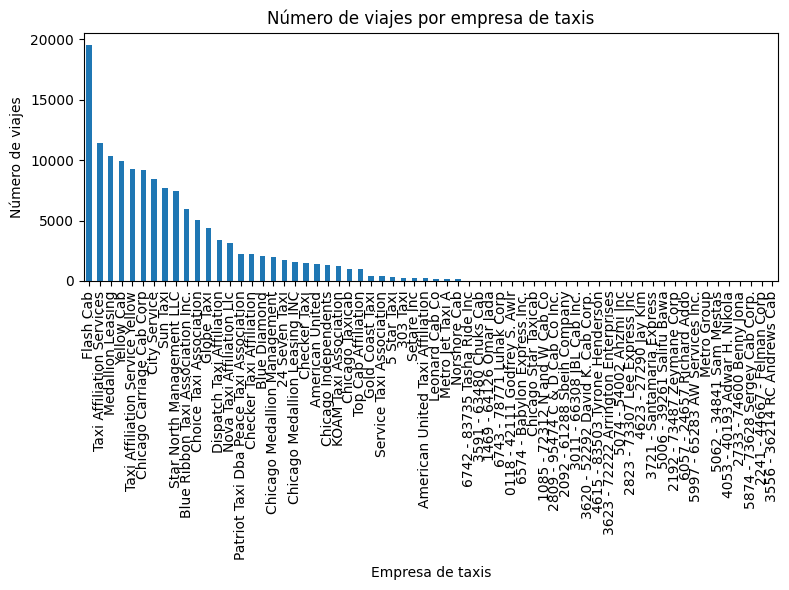

In [14]:
#Gráfica 1: Empresa de taxis y números de viajes
company_trips = df_company.sort_values(
    by="trips_amount",
    ascending=False
)

company_trips.plot(
    kind="bar",
    x="company_name",
    y="trips_amount",
    figsize=(8, 6),
    legend=False,
    title="Número de viajes por empresa de taxis"
)

plt.xlabel("Empresa de taxis")
plt.ylabel("Número de viajes")
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de mostrar el resultado, se puede observar la compañía que tiene más viajes agendados

Una manera alternativa de mostrar este grafico sería limitando el número de compañías, es decir, puedes elegir por ejemplo las primeras 15, esto no va a afectar ya que como se puede ver las últimas compañías no aportan mucho a la visualización
</div>

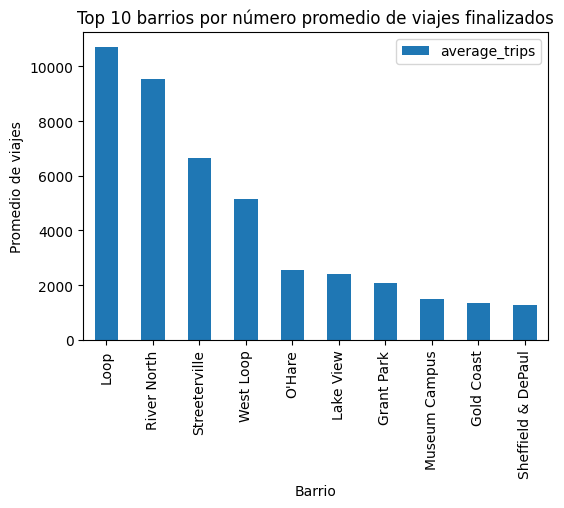

In [15]:
#Gráfica 2: 10 barrios principales
neighborhoods_trips = df_neighborhoods.sort_values(
    by="average_trips",
    ascending=False
).head(10)

neighborhoods_trips.plot(
    x='dropoff_location_name',
    y='average_trips',
    kind='bar',
    figsize=(6, 4),
    title='Top 10 barrios por número promedio de viajes finalizados'
)

plt.xlabel('Barrio')
plt.ylabel('Promedio de viajes')
plt.show()


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de crear una grafica que nos muestra los lugares más frecuentados
</div>

Conclusiones:

  Gráfica 1
- Se observa que la empresa que mayor concentra el número de viajes es Flash Cab, donde le sigue Taxi Affiliation Services quienes son las dos más grandes que dominan la demanda del servicio, demostrando una alta compentencia dentro del mercado.
- Se evidencia que las empresas que tienen por debajo de 5000 viajes son empresas pequeñas tratando de ser parte del mercado, sin embargo hay una gran diferencia entre las empresas consolidadas y las pequeñas empresas.
  
  Gráfica 2
- Los barrios con más finalizaciones del servicio son Loop River North, se presume que es debido a que hacen parte de zonas centrales o de alto flujo de comercio.
- El barrio con menor frecuencia de finalizaciones es Sheffield & DePaul, puede ser un barrio más alejado de los demás y por ende los conductores no toman esta ruta como preferida.

Prueba de hipótesis

Hipótesis planteadas 
- Hipótesis nula: La duración promedio de los viajes desde el Loop hasta O'Hare no cambia los sábados lluviosos
- Hipótesis alternativa: La duración promedio de los viajes desde el Loop hasta O'Hare sí cambia los sábados lluviosos.

Criterios 
- Se toma la prueba de t-student para dos muestras independientes

In [18]:
from scipy import stats

In [19]:
#Filtrar viajes de sábados lluviosos y los que no
rainy_saturdays = df_weather[df_weather['weather_conditions'] == 'Bad']['duration_seconds']
non_rainy_saturdays = df_weather[df_weather['weather_conditions'] == 'Good']['duration_seconds']

alpha = 0.05

results = stats.ttest_ind(
    rainy_saturdays,
    non_rainy_saturdays,
    equal_var=False
)

print('Valor p:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No rechazamos la hipótesis nula')
    

Valor p: 6.738994326108734e-12
Rechazamos la hipótesis nula


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Bien hecho!<br/>

Es correcto rechazar la hipotesis nula, debido a que sí hay notables cambios entre un día de buenas condiciones y uno con malas condiciones
</div>

Con un 0.00000000006738% rechazamos la hipotesis nula, donde demuestra que la duración promedio de los viajes desde el Loop hasta O'Hare si cambia los sábados lluviosos.

# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar las hipotesis con procesos estadisticos.<br/>    
<br/>    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
- El proyecto es directo y conciso
    
</div> 

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Desarrollar las conclusiones finales, puedes añadir lo que te pareció complicado del proyecto, que mejoras se pueden hacer, etc.

</div>